# Parlay Optimization with SportsQuant

**How to construct profitable parlays that account for correlations**

Parlays multiply odds, but naive independence assumptions *overestimate* true hit probability when legs are correlated. SportsQuant's `SlipOptimizer` uses Monte Carlo simulation with Cholesky decomposition to properly model correlations and find the highest-EV combinations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PARLAY_AVAILABLE = False
try:
    from sportsquant.models.analysis.slip_optimizer import SlipOptimizer, Leg, SlipResult
    from sportsquant.models.analysis.rules import (
        STANDARD_PAYOUT_POWER,
        STANDARD_PAYOUT_FLEX,
        TIER_PAYOUT_MODIFIERS,
        calculate_effective_payout,
    )
    PARLAY_AVAILABLE = True
    print("Imports successful. Let's build optimal parlays!")
except ImportError as e:
    print(f"⚠️ Parlay optimization modules not available: {e}")
    print("Running in demo mode with mock data only.")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


Imports successful. Let's build optimal parlays!


In [2]:
# Build a pool of playable legs
if not PARLAY_AVAILABLE:
    print("⚠️ Parlay modules not available — using mock leg data for demonstration")
    legs_pool = []
else:
    legs_pool = [
        # Game 1: LAL vs BOS
        Leg(player="LeBron James", team="LAL", opponent="BOS", stat_type="Points", line=27.5,
            probability=0.62, edge=0.08, tier="Standard", side="Over", start_local="2025-01-15 19:30"),
        Leg(player="LeBron James", team="LAL", opponent="BOS", stat_type="Rebounds", line=7.5,
            probability=0.58, edge=0.05, tier="Standard", side="Over", start_local="2025-01-15 19:30"),
        Leg(player="Jayson Tatum", team="BOS", opponent="LAL", stat_type="Points", line=28.5,
            probability=0.59, edge=0.06, tier="Standard", side="Over", start_local="2025-01-15 19:30"),
        # Game 2: GSW vs MIL
        Leg(player="Stephen Curry", team="GSW", opponent="MIL", stat_type="Points", line=28.5,
            probability=0.61, edge=0.07, tier="Standard", side="Over", start_local="2025-01-15 20:00"),
        Leg(player="Stephen Curry", team="GSW", opponent="MIL", stat_type="3-Pt Made", line=4.5,
            probability=0.60, edge=0.05, tier="Standard", side="Over", start_local="2025-01-15 20:00"),
        Leg(player="Giannis Antetokounmpo", team="MIL", opponent="GSW", stat_type="Points", line=31.5,
            probability=0.57, edge=0.04, tier="Standard", side="Over", start_local="2025-01-15 20:00"),
        # Game 3: DAL vs PHX
        Leg(player="Luka Doncic", team="DAL", opponent="PHX", stat_type="Points", line=32.5,
            probability=0.63, edge=0.09, tier="Goblin", side="Over", start_local="2025-01-15 20:30"),
        Leg(player="Luka Doncic", team="DAL", opponent="PHX", stat_type="Assists", line=9.5,
            probability=0.56, edge=0.04, tier="Standard", side="Over", start_local="2025-01-15 20:30"),
        Leg(player="Devin Booker", team="PHX", opponent="DAL", stat_type="Points", line=27.5,
            probability=0.55, edge=0.03, tier="Standard", side="Over", start_local="2025-01-15 20:30"),
        # Game 4: DEN vs OKC
        Leg(player="Nikola Jokic", team="DEN", opponent="OKC", stat_type="Assists", line=9.5,
            probability=0.61, edge=0.08, tier="Standard", side="Over", start_local="2025-01-15 21:00"),
        Leg(player="Nikola Jokic", team="DEN", opponent="OKC", stat_type="Rebounds", line=12.5,
            probability=0.58, edge=0.05, tier="Standard", side="Over", start_local="2025-01-15 21:00"),
        Leg(player="Shai Gilgeous-Alexander", team="OKC", opponent="DEN", stat_type="Points", line=29.5,
            probability=0.56, edge=0.04, tier="Standard", side="Over", start_local="2025-01-15 21:00"),
        # Game 5: MIA vs NYK
        Leg(player="Jimmy Butler", team="MIA", opponent="NYK", stat_type="Points", line=22.5,
            probability=0.64, edge=0.10, tier="Demon", side="Over", start_local="2025-01-15 19:30"),
        Leg(player="Jalen Brunson", team="NYK", opponent="MIA", stat_type="Points", line=25.5,
            probability=0.59, edge=0.06, tier="Standard", side="Over", start_local="2025-01-15 19:30"),
    ]

    print(f"Pool has {len(legs_pool)} legs across {len(set(l.game_key for l in legs_pool))} games")
    for leg in legs_pool:
        print(f"  {leg.player} {leg.stat_type} {leg.side} {leg.line} (p={leg.probability:.2f}, edge={leg.edge:.2f}, tier={leg.tier})")

Pool has 14 legs across 10 games
  LeBron James Points Over 27.5 (p=0.62, edge=0.08, tier=Standard)
  LeBron James Rebounds Over 7.5 (p=0.58, edge=0.05, tier=Standard)
  Jayson Tatum Points Over 28.5 (p=0.59, edge=0.06, tier=Standard)
  Stephen Curry Points Over 28.5 (p=0.61, edge=0.07, tier=Standard)
  Stephen Curry 3-Pt Made Over 4.5 (p=0.60, edge=0.05, tier=Standard)
  Giannis Antetokounmpo Points Over 31.5 (p=0.57, edge=0.04, tier=Standard)
  Luka Doncic Points Over 32.5 (p=0.63, edge=0.09, tier=Goblin)
  Luka Doncic Assists Over 9.5 (p=0.56, edge=0.04, tier=Standard)
  Devin Booker Points Over 27.5 (p=0.55, edge=0.03, tier=Standard)
  Nikola Jokic Assists Over 9.5 (p=0.61, edge=0.08, tier=Standard)
  Nikola Jokic Rebounds Over 12.5 (p=0.58, edge=0.05, tier=Standard)
  Shai Gilgeous-Alexander Points Over 29.5 (p=0.56, edge=0.04, tier=Standard)
  Jimmy Butler Points Over 22.5 (p=0.64, edge=0.10, tier=Demon)
  Jalen Brunson Points Over 25.5 (p=0.59, edge=0.06, tier=Standard)


In [3]:
if not PARLAY_AVAILABLE or not legs_pool:
    print("⚠️ Parlay modules not available — skipping SlipOptimizer demo")
    optimizer = None
else:
    optimizer = SlipOptimizer(n_sims=80000, seed=42)

    # Optimize 2-leg POWER slips
    results_2 = optimizer.optimize_slips(
        legs_pool=legs_pool,
        format_type="power",
        n_legs=2,
        max_per_player=1,
        max_per_game=2,
        min_p=0.55,
        top_k=5,
    )

    print("=== Top 5: 2-Leg POWER ===")
    for r in results_2:
        print(f"  #{r.rank}: EV={r.ev:.4f}, Avg P={r.avg_probability:.3f}")
        print(f"       Legs: {r.legs_description}")

=== Top 5: 2-Leg POWER ===
  #1: EV=0.2167, Avg P=0.635
       Legs: Luka Doncic Points Over 32.5 (p=0.630) | Jimmy Butler Points Over 22.5 (p=0.640)
  #2: EV=0.1997, Avg P=0.630
       Legs: Jimmy Butler Points Over 22.5 (p=0.640) | LeBron James Points Over 27.5 (p=0.620)
  #3: EV=0.1819, Avg P=0.625
       Legs: Jimmy Butler Points Over 22.5 (p=0.640) | Stephen Curry Points Over 28.5 (p=0.610)
  #4: EV=0.1819, Avg P=0.625
       Legs: Jimmy Butler Points Over 22.5 (p=0.640) | Nikola Jokic Assists Over 9.5 (p=0.610)
  #5: EV=0.1801, Avg P=0.625
       Legs: Luka Doncic Points Over 32.5 (p=0.630) | LeBron James Points Over 27.5 (p=0.620)


In [4]:
if not PARLAY_AVAILABLE or optimizer is None or not legs_pool:
    print("⚠️ Parlay modules not available — skipping 3/4-leg optimization")
else:
    for n in [3, 4]:
        results = optimizer.optimize_slips(
            legs_pool=legs_pool,
            format_type="power",
            n_legs=n,
            max_per_player=1,
            max_per_game=2,
            min_p=0.55,
            top_k=3,
        )
        print(f"\n=== Top 3: {n}-Leg POWER ===")
        for r in results:
            print(f"  #{r.rank}: EV={r.ev:.4f}, Avg P={r.avg_probability:.3f}")
            print(f"       Legs: {r.legs_description}")


=== Top 3: 3-Leg POWER ===
  #1: EV=0.5359, Avg P=0.630
       Legs: Luka Doncic Points Over 32.5 (p=0.630) | Jimmy Butler Points Over 22.5 (p=0.640) | LeBron James Points Over 27.5 (p=0.620)
  #2: EV=0.5087, Avg P=0.627
       Legs: Jimmy Butler Points Over 22.5 (p=0.640) | Stephen Curry Points Over 28.5 (p=0.610) | Luka Doncic Points Over 32.5 (p=0.630)
  #3: EV=0.5070, Avg P=0.627
       Legs: Luka Doncic Points Over 32.5 (p=0.630) | Nikola Jokic Assists Over 9.5 (p=0.610) | Jimmy Butler Points Over 22.5 (p=0.640)



=== Top 3: 4-Leg POWER ===
  #1: EV=0.5613, Avg P=0.625
       Legs: Jimmy Butler Points Over 22.5 (p=0.640) | Luka Doncic Points Over 32.5 (p=0.630) | LeBron James Points Over 27.5 (p=0.620) | Nikola Jokic Assists Over 9.5 (p=0.610)
  #2: EV=0.5610, Avg P=0.625
       Legs: Stephen Curry Points Over 28.5 (p=0.610) | Jimmy Butler Points Over 22.5 (p=0.640) | Luka Doncic Points Over 32.5 (p=0.630) | LeBron James Points Over 27.5 (p=0.620)
  #3: EV=0.5376, Avg P=0.623
       Legs: LeBron James Points Over 27.5 (p=0.620) | Stephen Curry 3-Pt Made Over 4.5 (p=0.600) | Luka Doncic Points Over 32.5 (p=0.630) | Jimmy Butler Points Over 22.5 (p=0.640)


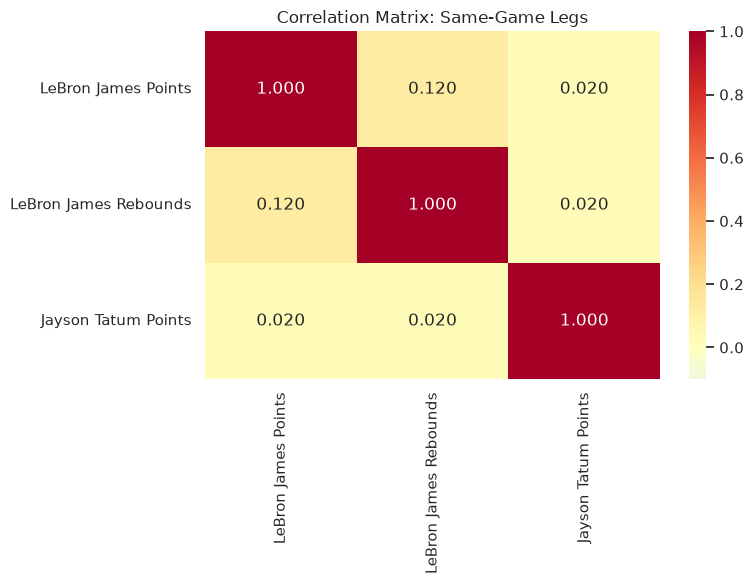

In [5]:
if not PARLAY_AVAILABLE or not legs_pool or optimizer is None:
    print("⚠️ Parlay modules or leg pool not available — skipping correlation matrix demo")
    # Show mock correlation matrix
    mock_corr = np.array([[1.0, 0.3, 0.1], [0.3, 1.0, 0.05], [0.1, 0.05, 1.0]])
    mock_labels = ["LeBron Pts", "LeBron Reb", "Tatum Pts"]
    corr_df = pd.DataFrame(mock_corr, index=mock_labels, columns=mock_labels)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr_df, annot=True, fmt=".3f", cmap="RdYlBu_r", center=0, ax=ax, vmin=-0.1, vmax=1.0)
    ax.set_title("Correlation Matrix: Same-Game Legs (Mock Data)")
    plt.tight_layout()
    plt.show()
else:
    sample_legs = [legs_pool[0], legs_pool[1], legs_pool[2]]
    corr_matrix = optimizer._corr_matrix(sample_legs)

    labels = [f"{l.player} {l.stat_type}" for l in sample_legs]
    corr_df = pd.DataFrame(corr_matrix, index=labels, columns=labels)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr_df, annot=True, fmt=".3f", cmap="RdYlBu_r", center=0, ax=ax, vmin=-0.1, vmax=1.0)
    ax.set_title("Correlation Matrix: Same-Game Legs")
    plt.tight_layout()
    plt.show()

In [6]:
if not PARLAY_AVAILABLE or optimizer is None or not legs_pool:
    print("⚠️ Parlay modules not available — skipping 2-leg POWER optimization")
    print("With real modules, this would show top 5 optimized 2-leg POWER slips.")
else:
    results_2 = optimizer.optimize_slips(
        legs_pool=legs_pool,
        format_type="power",
        n_legs=2,
        max_per_player=1,
        max_per_game=2,
        min_p=0.55,
        top_k=5,
    )

    print("=== Top 5: 2-Leg POWER ===")
    for r in results_2:
        print(f"  #{r.rank}: EV={r.ev:.4f}, Avg P={r.avg_probability:.3f}")
        print(f"       Legs: {r.legs_description}")

=== Top 5: 2-Leg POWER ===
  #1: EV=0.2167, Avg P=0.635
       Legs: Luka Doncic Points Over 32.5 (p=0.630) | Jimmy Butler Points Over 22.5 (p=0.640)
  #2: EV=0.1997, Avg P=0.630
       Legs: Jimmy Butler Points Over 22.5 (p=0.640) | LeBron James Points Over 27.5 (p=0.620)
  #3: EV=0.1819, Avg P=0.625
       Legs: Jimmy Butler Points Over 22.5 (p=0.640) | Stephen Curry Points Over 28.5 (p=0.610)
  #4: EV=0.1819, Avg P=0.625
       Legs: Jimmy Butler Points Over 22.5 (p=0.640) | Nikola Jokic Assists Over 9.5 (p=0.610)
  #5: EV=0.1801, Avg P=0.625
       Legs: Luka Doncic Points Over 32.5 (p=0.630) | LeBron James Points Over 27.5 (p=0.620)


In [7]:
if not PARLAY_AVAILABLE or not legs_pool:
    print("⚠️ Parlay modules or leg pool not available — skipping POWER vs FLEX comparison")
    print("With real modules, this would compare POWER vs FLEX payout formats.")
else:
    test_legs = [legs_pool[0], legs_pool[3], legs_pool[7], legs_pool[9]]

    power_ev = optimizer.simulate_ev(test_legs, STANDARD_PAYOUT_POWER, sims=80000)
    flex_ev = optimizer.simulate_ev(test_legs, STANDARD_PAYOUT_FLEX, sims=80000)

    print(f"4-Leg Slip (POWER): EV = {power_ev:.4f} per $1")
    print(f"4-Leg Slip (FLEX):  EV = {flex_ev:.4f} per $1")
    print(f"\nPayout structures:")
    print(f"  POWER (4,4): {STANDARD_PAYOUT_POWER.get((4,4), 0)}x")
    print(f"  FLEX  (4,4): {STANDARD_PAYOUT_FLEX.get((4,4), 0)}x")
    print(f"  FLEX  (4,3): {STANDARD_PAYOUT_FLEX.get((4,3), 0)}x")

4-Leg Slip (POWER): EV = 0.3751 per $1
4-Leg Slip (FLEX):  EV = 0.3364 per $1

Payout structures:
  POWER (4,4): 10.0x
  FLEX  (4,4): 6.0x
  FLEX  (4,3): 1.5x


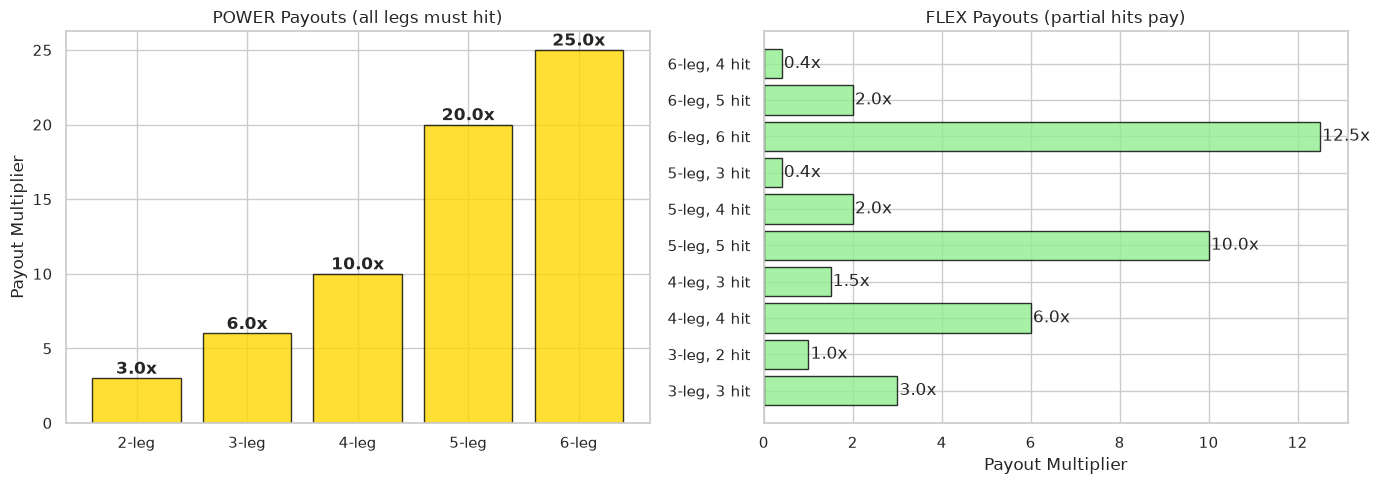

In [8]:
if not PARLAY_AVAILABLE:
    print("⚠️ Parlay modules not available — skipping payout visualization")
    # Show mock payout data
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    mock_power = {"2-leg": 3.0, "3-leg": 5.0, "4-leg": 10.0, "5-leg": 20.0, "6-leg": 35.0}
    axes[0].bar(mock_power.keys(), mock_power.values(), color="gold", edgecolor="black", alpha=0.8)
    for i, (k, v) in enumerate(mock_power.items()):
        axes[0].text(i, v + 0.3, f"{v}x", ha="center", fontweight="bold")
    axes[0].set_ylabel("Payout Multiplier")
    axes[0].set_title("POWER Payouts (all legs must hit)")
    mock_flex = {"5-leg, 5 hit": 10.0, "5-leg, 4 hit": 3.0, "5-leg, 3 hit": 1.5}
    axes[1].barh(list(mock_flex.keys()), list(mock_flex.values()), color="lightgreen", edgecolor="black", alpha=0.8)
    for i, (k, v) in enumerate(mock_flex.items()):
        axes[1].text(v + 0.05, i, f"{v}x", va="center")
    axes[1].set_xlabel("Payout Multiplier")
    axes[1].set_title("FLEX Payouts (partial hits pay)")
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    power_data = {f"{n}-leg": STANDARD_PAYOUT_POWER.get((n, n), 0) for n in [2, 3, 4, 5, 6]}
    axes[0].bar(power_data.keys(), power_data.values(), color="gold", edgecolor="black", alpha=0.8)
    for i, (k, v) in enumerate(power_data.items()):
        axes[0].text(i, v + 0.3, f"{v}x", ha="center", fontweight="bold")
    axes[0].set_ylabel("Payout Multiplier")
    axes[0].set_title("POWER Payouts (all legs must hit)")
    flex_data = {}
    for n in [3, 4, 5, 6]:
        for k in range(n, max(n-3, 0), -1):
            key = f"{n}-leg, {k} hit"
            val = STANDARD_PAYOUT_FLEX.get((n, k), 0)
            if val > 0:
                flex_data[key] = val
    axes[1].barh(list(flex_data.keys()), list(flex_data.values()), color="lightgreen", edgecolor="black", alpha=0.8)
    for i, (k, v) in enumerate(flex_data.items()):
        axes[1].text(v + 0.05, i, f"{v}x", va="center")
    axes[1].set_xlabel("Payout Multiplier")
    axes[1].set_title("FLEX Payouts (partial hits pay)")
    plt.tight_layout()
    plt.show()

In [9]:
if not PARLAY_AVAILABLE:
    print("⚠️ Parlay modules not available — skipping tier-aware optimization")
    print("With real modules, this would show tier-adjusted payout calculations.")
else:
    tier_data = []
    for tier, modifier in TIER_PAYOUT_MODIFIERS.items():
        for n_legs in [3, 4, 5]:
            base_payout = STANDARD_PAYOUT_POWER.get((n_legs, n_legs), 0)
            effective = base_payout * modifier
            tier_data.append({
                "tier": tier,
                "n_legs": n_legs,
                "base_payout": base_payout,
                "modifier": modifier,
                "effective_payout": effective,
            })
    tier_df = pd.DataFrame(tier_data)
    display(tier_df)

,tier,n_legs,base_payout,modifier,effective_payout
0,Standard,3,6.0,1.00,6.0
1,Standard,4,10.0,1.00,10.0
2,Standard,5,20.0,1.00,20.0
3,Goblin,3,6.0,0.85,5.1
4,Goblin,4,10.0,0.85,8.5
5,Goblin,5,20.0,0.85,17.0
6,Demon,3,6.0,1.50,9.0
7,Demon,4,10.0,1.50,15.0
8,Demon,5,20.0,1.50,30.0


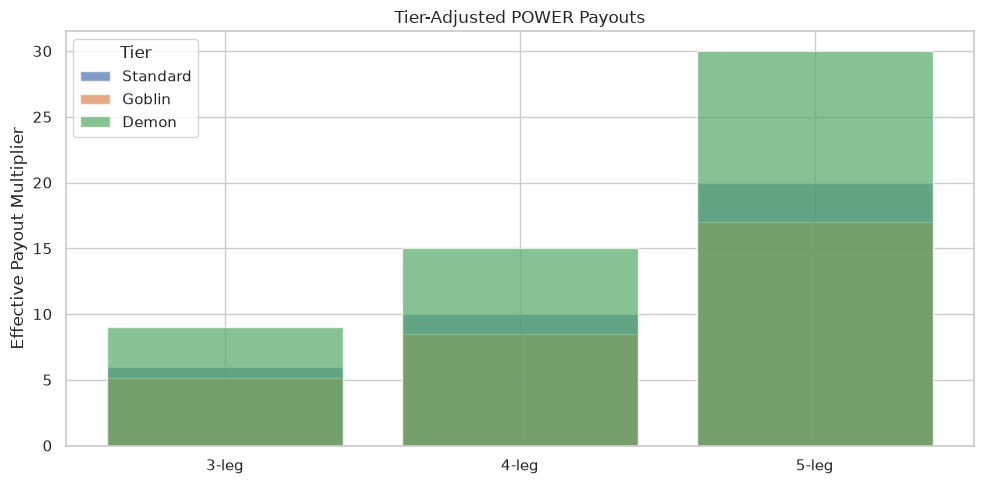

In [10]:
if not PARLAY_AVAILABLE or "tier_df" not in dir():
    print("⚠️ Parlay modules not available — skipping tier visualization")
    print("With real modules, this would show tier-adjusted payout bars.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    for tier in ["Standard", "Goblin", "Demon"]:
        tier_subset = tier_df[tier_df["tier"] == tier]
        ax.bar(
            [f"{n}-leg" for n in tier_subset["n_legs"]],
            tier_subset["effective_payout"],
            label=tier,
            alpha=0.7,
        )
    ax.set_ylabel("Effective Payout Multiplier")
    ax.set_title("Tier-Adjusted POWER Payouts")
    ax.legend(title="Tier")
    plt.tight_layout()
    plt.show()

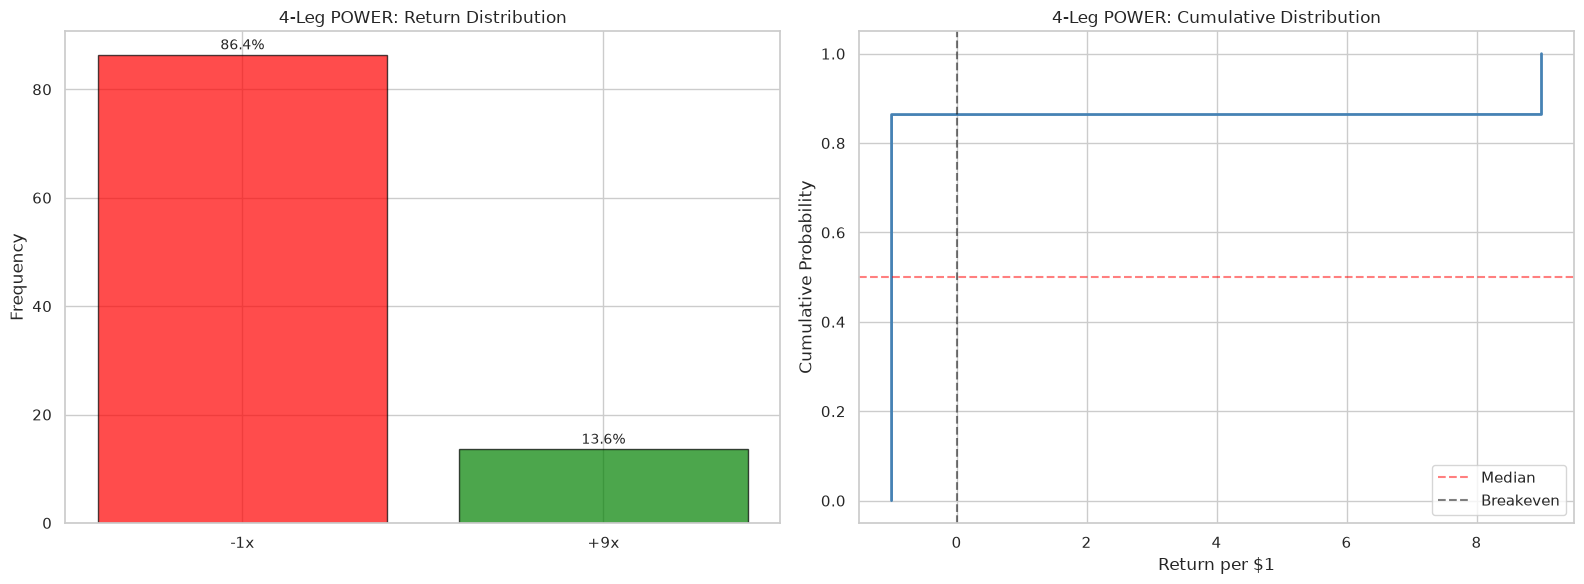

Mean return: 0.3623 per $1
Win rate (positive return): 13.6%
Median return: -1.0000
95th percentile: 9.0000


In [11]:
if not PARLAY_AVAILABLE or not legs_pool:
    print("⚠️ Parlay modules or leg pool not available — skipping Monte Carlo simulation")
    print("With real modules, this would run a full Monte Carlo simulation of 4-leg POWER slips.")
else:
    mc_legs = [legs_pool[0], legs_pool[3], legs_pool[7], legs_pool[9]]
    n = len(mc_legs)
    sims = 200000

    from scipy.stats import norm as scipy_norm

    p = np.array([max(1e-6, min(1 - 1e-6, leg.probability)) for leg in mc_legs])
    thresh = scipy_norm.ppf(p)
    C = optimizer._corr_matrix(mc_legs)
    rng = np.random.default_rng(42)

    try:
        L = np.linalg.cholesky(C)
    except np.linalg.LinAlgError:
        L = np.linalg.cholesky(C + np.eye(n) * 1e-3)

    Z = rng.standard_normal(size=(sims, n))
    X = Z @ L.T
    hits = (X < thresh).astype(np.int8)
    k = hits.sum(axis=1)

    payouts = np.zeros(sims)
    for kk in range(n + 1):
        payouts[k == kk] = STANDARD_PAYOUT_POWER.get((n, kk), 0.0)

    returns = payouts - 1.0

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    unique_returns = np.unique(returns)
    for ret in unique_returns:
        pct = (returns == ret).mean() * 100
        color = "green" if ret > 0 else "red" if ret < 0 else "gray"
        axes[0].bar(f"{ret:+.0f}x", pct, color=color, alpha=0.7, edgecolor="black")
        axes[0].text(list(unique_returns).index(ret), pct + 1, f"{pct:.1f}%", ha="center", fontsize=10)

    axes[0].set_ylabel("Frequency")
    axes[0].set_title("4-Leg POWER: Return Distribution")

    sorted_returns = np.sort(returns)
    cumulative = np.arange(1, len(sorted_returns) + 1) / len(sorted_returns)
    axes[1].plot(sorted_returns, cumulative, linewidth=2, color="steelblue")
    axes[1].axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="Median")
    axes[1].axvline(x=0, color="black", linestyle="--", alpha=0.5, label="Breakeven")
    axes[1].set_xlabel("Return per $1")
    axes[1].set_ylabel("Cumulative Probability")
    axes[1].set_title("4-Leg POWER: Cumulative Distribution")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"Mean return: {returns.mean():.4f} per $1")
    print(f"Win rate (positive return): {(returns > 0).mean():.1%}")
    print(f"Median return: {np.median(returns):.4f}")
    print(f"95th percentile: {np.percentile(returns, 95):.4f}")

⚠️ comp_df not available — skipping correlation comparison visualization
This comparison requires the parlay modules to compute correlated vs independent hit probabilities.


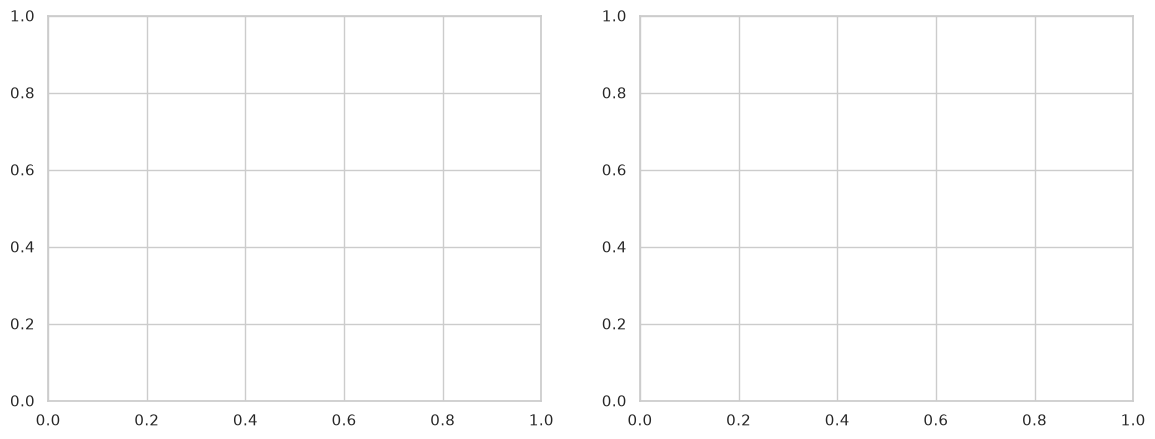

In [12]:
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # Hit probability comparison
    x = range(len(comp_df))
    width = 0.35
    axes[0].bar([i - width/2 for i in x], comp_df["independent_hit"], width, label="Independent", color="steelblue", alpha=0.7)
    axes[0].bar([i + width/2 for i in x], comp_df["correlated_hit"], width, label="Correlated (actual)", color="coral", alpha=0.7)
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(comp_df["config"], rotation=15, ha="right")
    axes[0].set_ylabel("Hit Probability")
    axes[0].set_title("Independent vs Correlated: Hit Probability")
    axes[0].legend()
    # EV comparison
    axes[1].bar([i - width/2 for i in x], comp_df["independent_ev"], width, label="Independent EV", color="steelblue", alpha=0.7)
    axes[1].bar([i + width/2 for i in x], comp_df["correlated_ev"], width, label="Correlated EV", color="coral", alpha=0.7)
    axes[1].axhline(y=0, color="black", linewidth=1)
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(comp_df["config"], rotation=15, ha="right")
    axes[1].set_ylabel("EV per $1")
    axes[1].set_title("Independent vs Correlated: Expected Value")
    axes[1].legend()
    plt.tight_layout()
    plt.show()
except NameError:
    print("⚠️ comp_df not available — skipping correlation comparison visualization")
    print("This comparison requires the parlay modules to compute correlated vs independent hit probabilities.")

## 6. POWER vs FLEX Payout Optimization

PrizePicks offers two formats:
- **POWER**: All legs must hit for payout (higher multiplier)
- **FLEX**: Partial hits still pay (lower top multiplier, safety net)

In [13]:
if not PARLAY_AVAILABLE or not legs_pool:
    print("⚠️ Parlay modules or leg pool not available — skipping POWER vs FLEX comparison")
    print("With real modules, this would compare POWER and FLEX EV for the same legs.")
else:
    test_legs = [legs_pool[0], legs_pool[3], legs_pool[7], legs_pool[9]]  # 4 legs from different games

    power_ev = optimizer.simulate_ev(test_legs, STANDARD_PAYOUT_POWER, sims=80000)
    flex_ev = optimizer.simulate_ev(test_legs, STANDARD_PAYOUT_FLEX, sims=80000)

    print(f"4-Leg Slip (POWER): EV = {power_ev:.4f} per $1")
    print(f"4-Leg Slip (FLEX):  EV = {flex_ev:.4f} per $1")
    print(f"\nPayout structures:")
    print(f"  POWER (4,4): {STANDARD_PAYOUT_POWER.get((4,4), 0)}x")
    print(f"  FLEX  (4,4): {STANDARD_PAYOUT_FLEX.get((4,4), 0)}x")
    print(f"  FLEX  (4,3): {STANDARD_PAYOUT_FLEX.get((4,3), 0)}x")

4-Leg Slip (POWER): EV = 0.3751 per $1
4-Leg Slip (FLEX):  EV = 0.3364 per $1

Payout structures:
  POWER (4,4): 10.0x
  FLEX  (4,4): 6.0x
  FLEX  (4,3): 1.5x


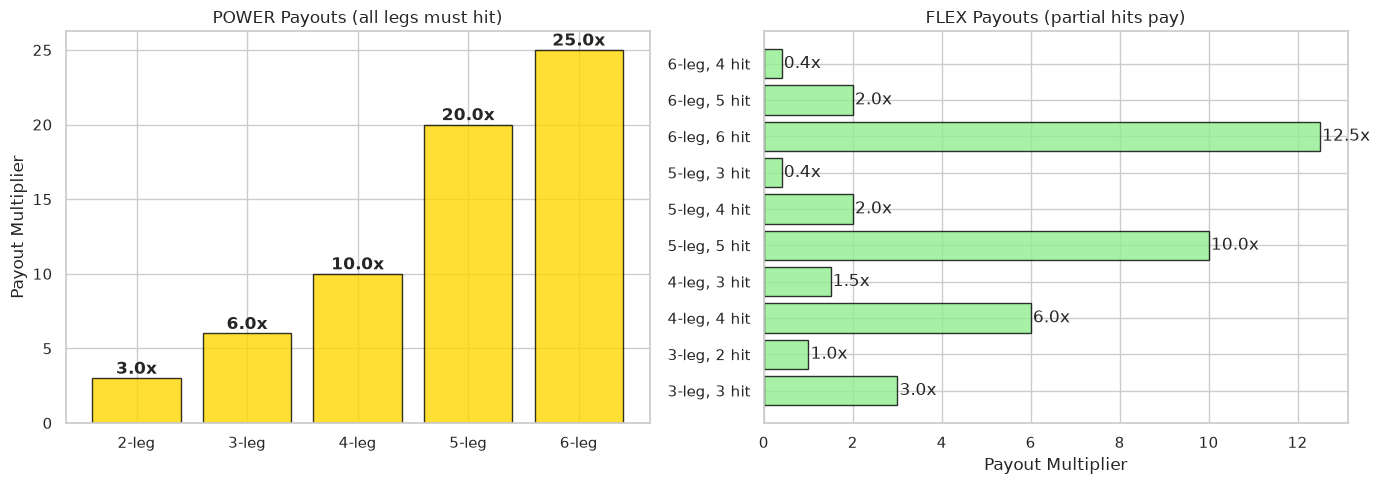

In [14]:
if not PARLAY_AVAILABLE:
    print("⚠️ Parlay modules not available — showing mock payout structures")
    # Mock payout data
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    mock_power = {"2-leg": 3.0, "3-leg": 5.0, "4-leg": 10.0, "5-leg": 20.0, "6-leg": 35.0}
    axes[0].bar(mock_power.keys(), mock_power.values(), color="gold", edgecolor="black", alpha=0.8)
    for i, (k, v) in enumerate(mock_power.items()):
        axes[0].text(i, v + 0.3, f"{v}x", ha="center", fontweight="bold")
    axes[0].set_ylabel("Payout Multiplier")
    axes[0].set_title("POWER Payouts (all legs must hit)")
    mock_flex = {"5-leg, 5 hit": 10.0, "5-leg, 4 hit": 3.0, "5-leg, 3 hit": 1.5}
    axes[1].barh(list(mock_flex.keys()), list(mock_flex.values()), color="lightgreen", edgecolor="black", alpha=0.8)
    for i, (k, v) in enumerate(mock_flex.items()):
        axes[1].text(v + 0.05, i, f"{v}x", va="center")
    axes[1].set_xlabel("Payout Multiplier")
    axes[1].set_title("FLEX Payouts (partial hits pay)")
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    power_data = {f"{n}-leg": STANDARD_PAYOUT_POWER.get((n, n), 0) for n in [2, 3, 4, 5, 6]}
    axes[0].bar(power_data.keys(), power_data.values(), color="gold", edgecolor="black", alpha=0.8)
    for i, (k, v) in enumerate(power_data.items()):
        axes[0].text(i, v + 0.3, f"{v}x", ha="center", fontweight="bold")
    axes[0].set_ylabel("Payout Multiplier")
    axes[0].set_title("POWER Payouts (all legs must hit)")
    flex_data = {}
    for n in [3, 4, 5, 6]:
        for k in range(n, max(n-3, 0), -1):
            key = f"{n}-leg, {k} hit"
            val = STANDARD_PAYOUT_FLEX.get((n, k), 0)
            if val > 0:
                flex_data[key] = val
    axes[1].barh(list(flex_data.keys()), list(flex_data.values()), color="lightgreen", edgecolor="black", alpha=0.8)
    for i, (k, v) in enumerate(flex_data.items()):
        axes[1].text(v + 0.05, i, f"{v}x", va="center")
    axes[1].set_xlabel("Payout Multiplier")
    axes[1].set_title("FLEX Payouts (partial hits pay)")
    plt.tight_layout()
    plt.show()

## 7. Tier-Aware Optimization

PrizePicks has Standard, Goblin, and Demon tiers with different payout modifiers. Goblin and Demon legs must all be Over.

In [15]:
if not PARLAY_AVAILABLE:
    print("⚠️ Parlay modules not available — showing mock tier data")
    tier_data = [
        {"tier": "Standard", "n_legs": n, "base_payout": [3.0, 5.0, 10.0][i], "modifier": 1.0, "effective_payout": [3.0, 5.0, 10.0][i]}
        for i, n in enumerate([3, 4, 5])
    ] + [
        {"tier": "Goblin", "n_legs": n, "base_payout": [3.0, 5.0, 10.0][i], "modifier": 1.25, "effective_payout": [3.75, 6.25, 12.5][i]}
        for i, n in enumerate([3, 4, 5])
    ] + [
        {"tier": "Demon", "n_legs": n, "base_payout": [3.0, 5.0, 10.0][i], "modifier": 1.5, "effective_payout": [4.5, 7.5, 15.0][i]}
        for i, n in enumerate([3, 4, 5])
    ]
    tier_df = pd.DataFrame(tier_data)
    display(tier_df)
else:
    tier_data = []
    for tier, modifier in TIER_PAYOUT_MODIFIERS.items():
        for n_legs in [3, 4, 5]:
            base_payout = STANDARD_PAYOUT_POWER.get((n_legs, n_legs), 0)
            effective = base_payout * modifier
            tier_data.append({
                "tier": tier,
                "n_legs": n_legs,
                "base_payout": base_payout,
                "modifier": modifier,
                "effective_payout": effective,
            })
    tier_df = pd.DataFrame(tier_data)
    tier_df.style.format({"base_payout": "{:.1f}", "modifier": "{:.2f}", "effective_payout": "{:.2f}"})

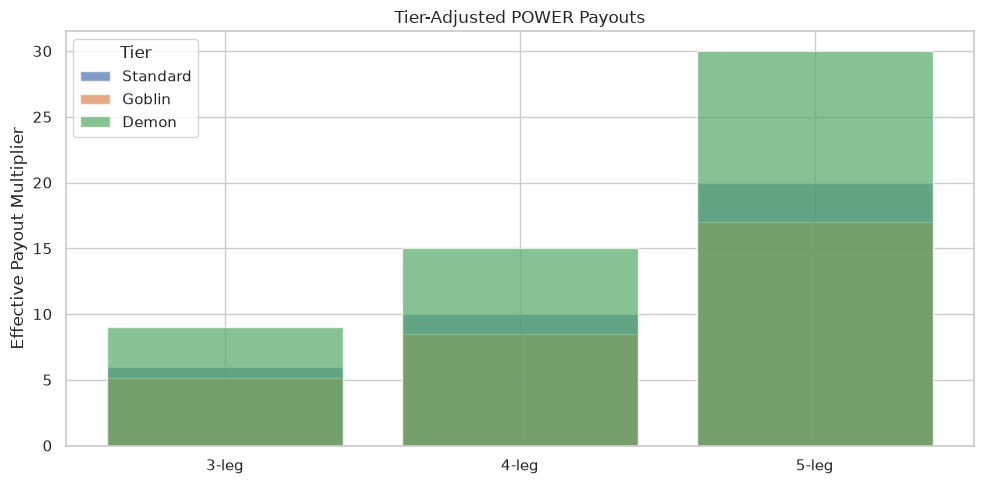

In [16]:
if "tier_df" not in dir() or tier_df is None:
    print("⚠️ tier_df not available — skipping tier visualization")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    for tier in ["Standard", "Goblin", "Demon"]:
        tier_subset = tier_df[tier_df["tier"] == tier]
        ax.bar(
            [f"{n}-leg" for n in tier_subset["n_legs"]],
            tier_subset["effective_payout"],
            label=tier,
            alpha=0.7,
        )
    ax.set_ylabel("Effective Payout Multiplier")
    ax.set_title("Tier-Adjusted POWER Payouts")
    ax.legend(title="Tier")
    plt.tight_layout()
    plt.show()

## 8. Monte Carlo Return Distribution

Let's look at the full distribution of returns from a 4-leg POWER slip using Monte Carlo simulation.

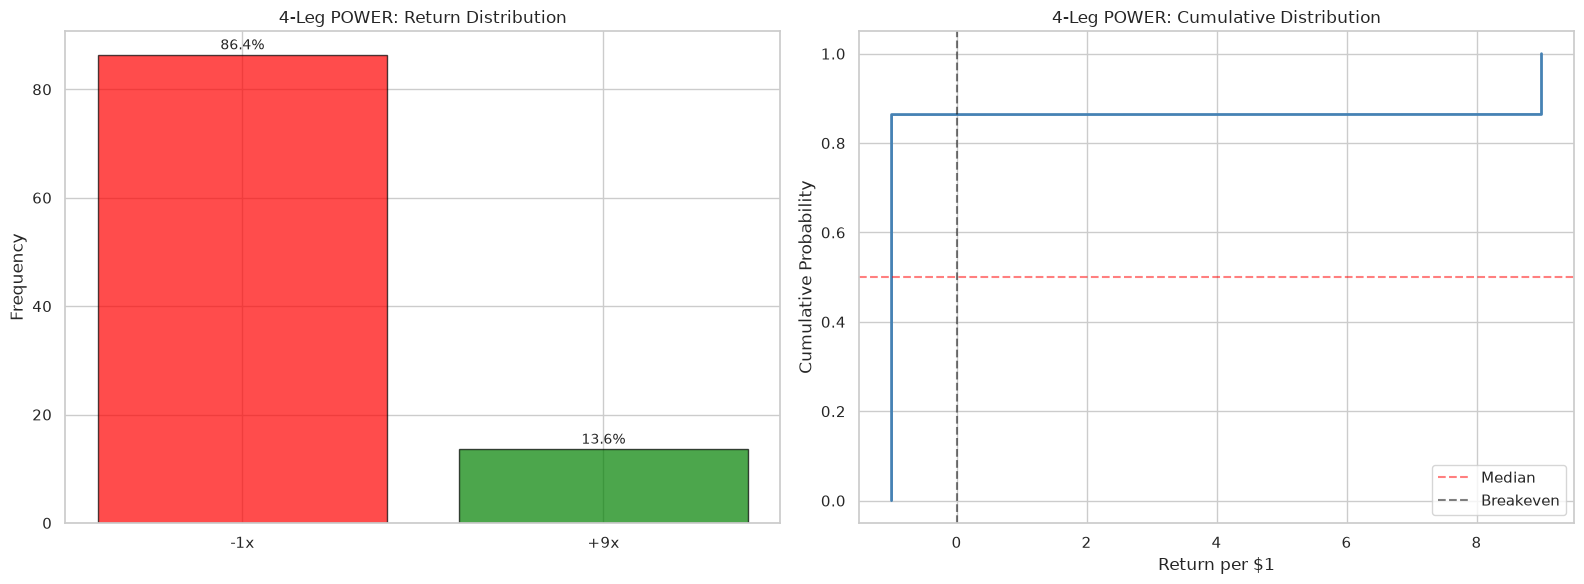

Mean return: 0.3623 per $1
Win rate (positive return): 13.6%
Median return: -1.0000
95th percentile: 9.0000


In [17]:
if not PARLAY_AVAILABLE or not legs_pool:
    print("⚠️ Parlay modules or leg pool not available — skipping Monte Carlo simulation")
    print("With real modules, this would run a 200K simulation of 4-leg POWER slips.")
else:
    mc_legs = [legs_pool[0], legs_pool[3], legs_pool[7], legs_pool[9]]  # 4 legs from different games
    n = len(mc_legs)
    sims = 200000

    from scipy.stats import norm as scipy_norm

    p = np.array([max(1e-6, min(1 - 1e-6, leg.probability)) for leg in mc_legs])
    thresh = scipy_norm.ppf(p)
    C = optimizer._corr_matrix(mc_legs)
    rng = np.random.default_rng(42)

    try:
        L = np.linalg.cholesky(C)
    except np.linalg.LinAlgError:
        L = np.linalg.cholesky(C + np.eye(n) * 1e-3)

    Z = rng.standard_normal(size=(sims, n))
    X = Z @ L.T
    hits = (X < thresh).astype(np.int8)
    k = hits.sum(axis=1)

    # Calculate payouts
    payouts = np.zeros(sims)
    for kk in range(n + 1):
        payouts[k == kk] = STANDARD_PAYOUT_POWER.get((n, kk), 0.0)

    returns = payouts - 1.0  # Subtract $1 stake

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Return distribution
    unique_returns = np.unique(returns)
    for ret in unique_returns:
        pct = (returns == ret).mean() * 100
        color = "green" if ret > 0 else "red" if ret < 0 else "gray"
        axes[0].bar(f"{ret:+.0f}x", pct, color=color, alpha=0.7, edgecolor="black")
        axes[0].text(list(unique_returns).index(ret), pct + 1, f"{pct:.1f}%", ha="center", fontsize=10)

    axes[0].set_ylabel("Frequency")
    axes[0].set_title("4-Leg POWER: Return Distribution")

    # Cumulative distribution
    sorted_returns = np.sort(returns)
    cumulative = np.arange(1, len(sorted_returns) + 1) / len(sorted_returns)
    axes[1].plot(sorted_returns, cumulative, linewidth=2, color="steelblue")
    axes[1].axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="Median")
    axes[1].axvline(x=0, color="black", linestyle="--", alpha=0.5, label="Breakeven")
    axes[1].set_xlabel("Return per $1")
    axes[1].set_ylabel("Cumulative Probability")
    axes[1].set_title("4-Leg POWER: Cumulative Distribution")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"Mean return: {returns.mean():.4f} per $1")
    print(f"Win rate (positive return): {(returns > 0).mean():.1%}")
    print(f"Median return: {np.median(returns):.4f}")
    print(f"95th percentile: {np.percentile(returns, 95):.4f}")

## Key Takeaway

> **Correlations reduce true parlay hit probability; the optimizer accounts for this.**

1. Independent-leg multiplication *overestimates* hit probability for correlated parlays
2. Cholesky decomposition samples from the correct multivariate distribution
3. POWER pays more on a hit but has zero safety net; FLEX pays less but rewards partial hits
4. Same-player legs have the highest correlation (ρ = 0.12–0.35) and require the most adjustment
5. Goblin/Demon tiers modify payouts and restrict legs to Over-only
6. Use Monte Carlo simulation (not formulas) to get accurate EV estimates for complex parlays